# Data generation — Rabi oscillation under continuous homodyne measurement
---
Simulates the conditional dynamics of a driven qubit measured along one of
$\hat\sigma_x, \hat\sigma_y, \hat\sigma_z$ at fixed measurement efficiency $\eta$, and
exports tensors used for training and full evaluation of the LSTMKraus model.

Hamiltonian and collapse operators:

$$ \hat H = \frac{\Omega}{2}\hat\sigma_x $$
$$ \hat C_\text{mon}   = \sqrt{\eta\,\kappa}\,\hat\sigma_b,\qquad
   \hat C_\text{unmon} = \sqrt{(1-\eta)\,\kappa}\,\hat\sigma_b,\qquad
   \hat C_\text{decay} = \sqrt{\gamma_d}\,\hat\sigma_- $$

In [3]:
import numpy as np
import os
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]
import torch
import matplotlib.pyplot as plt

from constants import *
from help_functions import generate_trajectories, normalize_J, t32, t64_c, tlong
import plot_style as ps

In [4]:
SUFFIX = '_const'   # '_vary' or '_const'

OMEGA_SPREAD_USED = 0.0 if SUFFIX == '_const' else OMEGA_SPREAD
print(f'OMEGA_SPREAD_USED = {OMEGA_SPREAD_USED}   saving to *{SUFFIX}_N*.pt')

OMEGA_SPREAD_USED = 0.0   saving to *_const_N*.pt


In [ ]:
TASK_Z, TASK_X, TASK_Y = 0, 1, 2 #corresonds to different measurement directions

---
### Generate training + validation data
Trajectories are split 80/20 into training and validation sets.

In [6]:
N_train = 10000   # trajectories per measurement basis

J_z, y_z, P_z, omegas_z = generate_trajectories(N_train, 'z', omega_rel_spread=OMEGA_SPREAD_USED)
J_x, y_x, P_x, omegas_x = generate_trajectories(N_train, 'x', omega_rel_spread=OMEGA_SPREAD_USED)
J_y, y_y, P_y, omegas_y = generate_trajectories(N_train, 'y', omega_rel_spread=OMEGA_SPREAD_USED)

J_z, J_x, J_y = normalize_J(J_z, dt), normalize_J(J_x, dt), normalize_J(J_y, dt)

n_tr  = int(0.8 * N_train)
n_val = N_train - n_tr

J_train      = torch.cat([t32(J_z[:n_tr]),       t32(J_x[:n_tr]),       t32(J_y[:n_tr])])
y_train      = torch.cat([t32(y_z[:n_tr]),       t32(y_x[:n_tr]),       t32(y_y[:n_tr])])
P_train      = torch.cat([t32(P_z[:n_tr]),       t32(P_x[:n_tr]),       t32(P_y[:n_tr])])
task_train   = torch.cat([tlong(n_tr, TASK_Z),   tlong(n_tr, TASK_X),   tlong(n_tr, TASK_Y)])
omegas_train = torch.cat([t32(omegas_z[:n_tr]),  t32(omegas_x[:n_tr]),  t32(omegas_y[:n_tr])])

J_val      = torch.cat([t32(J_z[n_tr:]),       t32(J_x[n_tr:]),       t32(J_y[n_tr:])])
y_val      = torch.cat([t32(y_z[n_tr:]),       t32(y_x[n_tr:]),       t32(y_y[n_tr:])])
P_val      = torch.cat([t32(P_z[n_tr:]),       t32(P_x[n_tr:]),       t32(P_y[n_tr:])])
task_val   = torch.cat([tlong(n_val, TASK_Z),  tlong(n_val, TASK_X),  tlong(n_val, TASK_Y)])
omegas_val = torch.cat([t32(omegas_z[n_tr:]),  t32(omegas_x[n_tr:]),  t32(omegas_y[n_tr:])])

torch.save({
    'J_train':      J_train,
    'y_train':      y_train,
    'P_train':      P_train,
    'task_train':   task_train,
    'omegas_train': omegas_train,
    'J_val':        J_val,
    'y_val':        y_val,
    'P_val':        P_val,
    'task_val':     task_val,
    'omegas_val':   omegas_val,
    'eta':          ETA,
}, f'data/training_data{SUFFIX}_N{N_train}.pt')
print(f'Saved data/training_data{SUFFIX}_N{N_train}.pt')

Saved data/training_data_const_N10000.pt


---
### Generate evaluation data
Stores conditional density matrices `rho_eval` (ground truth) for every time
step — required by the evaluation notebook.

In [5]:
N_eval = 10000   # trajectories per measurement basis

J_ez, y_ez, P_z, rho_z, omegas_ez = generate_trajectories(N_eval, 'z', 'test', omega_rel_spread=OMEGA_SPREAD_USED)
J_ex, y_ex, P_x, rho_x, omegas_ex = generate_trajectories(N_eval, 'x', 'test', omega_rel_spread=OMEGA_SPREAD_USED)
J_ey, y_ey, P_y, rho_y, omegas_ey = generate_trajectories(N_eval, 'y', 'test', omega_rel_spread=OMEGA_SPREAD_USED)

J_ez, J_ex, J_ey = normalize_J(J_ez, dt), normalize_J(J_ex, dt), normalize_J(J_ey, dt)

J_eval      = torch.cat([t32(J_ez),       t32(J_ex),       t32(J_ey)])
y_eval      = torch.cat([t32(y_ez),       t32(y_ex),       t32(y_ey)])
P_eval      = torch.cat([t32(P_z),        t32(P_x),        t32(P_y)])
rho_eval    = torch.cat([t64_c(rho_z),    t64_c(rho_x),    t64_c(rho_y)])
task_eval   = torch.cat([tlong(N_eval, TASK_Z), tlong(N_eval, TASK_X), tlong(N_eval, TASK_Y)])
omegas_eval = torch.cat([t32(omegas_ez),  t32(omegas_ex),  t32(omegas_ey)])

torch.save({
    'J_eval':      J_eval,
    'y_eval':      y_eval,
    'P_eval':      P_eval,
    'rho_eval':    rho_eval,
    'task_eval':   task_eval,
    'omegas_eval': omegas_eval,
    'eta':         ETA,
}, f'data/evaluation_data{SUFFIX}_N{N_eval}.pt')
print(f'Saved data/evaluation_data{SUFFIX}_N{N_eval}.pt')

Saved data/evaluation_data_const_N10000.pt


---
### Sample trajectory inspection
One $\hat\sigma_z$-trajectory showing the measurement record $J(t)$ alongside
$\rho_{00}$, $\mathrm{Re}\,\rho_{01}$ and $\mathrm{Im}\,\rho_{01}$.

'figures/sample_trajectory.pdf'

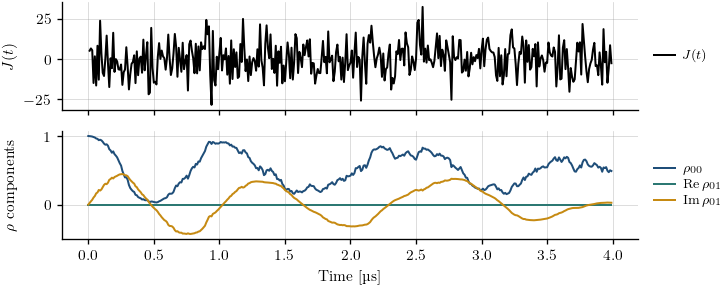

In [ ]:
J_s, _, _, rho_s, omegas_s = generate_trajectories(1, 'z', 'test', omega_rel_spread=OMEGA_SPREAD_USED)
J_s, rho_s = J_s[0], rho_s[0]

fig, (ax_J, ax_rho) = plt.subplots(2, 1, sharex=True,
                                   figsize=ps.figsize(ps.FULLWIDTH_IN, aspect=2.4))

ax_J.plot(times[1:], J_s, color='black', lw=1.2, label=r'$J(t)$')
ax_J.set_ylabel(r'$J(t)$')
ax_J.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)

ax_rho.plot(times, rho_s[:, 0, 0].real,  color=ps.PALETTE['blue'],  lw=1.2, label=r'$\rho_{00}$')
ax_rho.plot(times, rho_s[:, 0, 1].real,  color=ps.PALETTE['teal'],  lw=1.2, label=r'$\mathrm{Re}\,\rho_{01}$')
ax_rho.plot(times, rho_s[:, 0, 1].imag,  color=ps.PALETTE['ochre'], lw=1.2, label=r'$\mathrm{Im}\,\rho_{01}$')
ax_rho.set_ylabel(r'$\rho$ components')
ax_rho.set_xlabel(r'Time [µs]')
ax_rho.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)

fig.align_ylabels((ax_J, ax_rho))
fig.tight_layout()
ps.save_fig(fig, 'sample_trajectory')